# v4 rank-average confidence -> DCASE baseline

`v4` combines the v3 binary score and v2 expected score. For the requested `>=2`, `>=3`, `>=4` dataset grid, `rank_average_binary_score` is converted to a 1-5 pseudo confidence score with `1 + 4 * rank_average_binary_score`.

The fixed `final_test 20%` is held out before scoring/filtering and is only used for final evaluation.

In [1]:
from pathlib import Path
import sys

HERE = Path.cwd()
if not (HERE / 'confidence_baseline_common.py').exists():
    sys.path.insert(0, str(HERE / 'baseline_confidnce_train'))
else:
    sys.path.insert(0, str(HERE))

from confidence_baseline_common import ROOT, load_prediction_csv, run_downstream_grid, confidence_threshold_specs, load_baseline_assets, make_fixed_holdout

SEED = 1821
BASELINE_MODES = ('both',)
USE_KFOLD = True
N_FOLDS = 5
NUM_EPOCHS = 100
BATCH_SIZE = 64

OUTPUT_ROOT = ROOT / 'baseline_confidnce_train' / 'outputs' / 'v4_rank_average'
full_df, _, _ = load_baseline_assets(ROOT)
train_pool, final_test, _ = make_fixed_holdout(full_df, OUTPUT_ROOT, seed=SEED)

score_df = load_prediction_csv(ROOT / 'outputs' / 'confidence_filter_v4' / 'predictions' / 'BSD10k_oof_v4_scores.csv')
score_df = score_df[score_df['sound_id'].isin(set(train_pool['index'].astype(str)))].copy()
score_df = score_df[['sound_id', 'rank_average_binary_score', 'binary_mlp_prob', 'fiveclass_score', 'fiveclass_p45']].copy()
score_df['predicted_confidence_score'] = 1.0 + 4.0 * score_df['rank_average_binary_score'].astype(float)
score_df.head()

,sound_id,rank_average_binary_score,binary_mlp_prob,fiveclass_score,fiveclass_p45,predicted_confidence_score
0,185755,0.305677,0.599564,3.230088,0.332956,2.222709
3,432206,0.519396,0.619771,3.744333,0.744936,3.077583
4,80630,0.916028,0.960568,4.095646,0.966832,4.664111
6,145544,0.196422,0.417653,3.279489,0.424473,1.785688
7,156796,0.266521,0.391700,3.517829,0.635668,2.066082


In [2]:
summary, filter_counts = run_downstream_grid(
    experiment_name='v4_rank_average_scaled_to_1_5',
    score_df=score_df,
    output_root=OUTPUT_ROOT,
    score_col='predicted_confidence_score',
    threshold_specs=confidence_threshold_specs([2, 3, 4]),
    baseline_modes=BASELINE_MODES,
    use_kfold=USE_KFOLD,
    n_folds=N_FOLDS,
    seed=SEED,
    num_epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
)
display(filter_counts)
summary


=== Filter counts ===
filter_label               score_column  threshold  display_threshold  train_pool_samples  retained_samples  dropped_samples  retained_ratio  num_classes_retained
   pred_ge_2 predicted_confidence_score        2.0                  2                8764              6676             2088        0.761753                    23
   pred_ge_3 predicted_confidence_score        3.0                  3                8764              4373             4391        0.498973                    23
   pred_ge_4 predicted_confidence_score        4.0                  4                8764              2090             6674        0.238476                    19

=== Downstream baseline plan ===
experiment=v4_rank_average_scaled_to_1_5
device=cuda:0 (NVIDIA GeForce RTX 3060, 8.6 GB)
baseline_modes=('both',)
use_kfold=True, n_folds=5
thresholds=[2, 3, 4]
planned_trainings=15
num_epochs=100, batch_size=64

[run] c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v

c:\Users\solok\Desktop\Dcase baseline\dcase2026_task1_baseline\evaluate.py:97: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location

[BaseClassifier | Fold final_test] Accuracy: 76.73%
[BaseClassifier | Fold final_test] Top class accuracy: 86.18%
[BaseClassifier | Fold final_test] Macro accuracy: 69.14%
[BaseClassifier | Fold final_test] Macro top class accuracy: 81.73%
[BaseClassifier | Fold final_test] Hierarchical accuracy: 75.44%
[BaseClassifier | Fold final_test] Hierarchical precision: 75.87%
[BaseClassifier | Fold final_test] Hierarchical recall: 73.86%
[BaseClassifier | Fold final_test] Hierarchical F1: 73.62%
  completed in 4.8 min

[run] c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_rank_average\pred_ge_2\both\fold_1
  device=cuda:0 (NVIDIA GeForce RTX 3060, 8.6 GB)
  samples: train=5341, val=1335, final_test=2192
  batches: train=83, val=21, test=35
  max_epochs=100, batch_size=64
Epoch [1/100] - Val acc: 61.27%
  New best model saved
Epoch [2/100] - Val acc: 75.96%
  New best model saved
Epoch [3/100] - Val acc: 80.52%
  New best model saved
Epoch [4/100] - Val acc: 82.02%
  N

c:\Users\solok\Desktop\Dcase baseline\dcase2026_task1_baseline\evaluate.py:97: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location

[BaseClassifier | Fold final_test] Accuracy: 76.92%
[BaseClassifier | Fold final_test] Top class accuracy: 87.36%
[BaseClassifier | Fold final_test] Macro accuracy: 69.60%
[BaseClassifier | Fold final_test] Macro top class accuracy: 82.84%
[BaseClassifier | Fold final_test] Hierarchical accuracy: 76.22%
[BaseClassifier | Fold final_test] Hierarchical precision: 75.72%
[BaseClassifier | Fold final_test] Hierarchical recall: 74.57%
[BaseClassifier | Fold final_test] Hierarchical F1: 74.77%
  completed in 11.4 min

[run] c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_rank_average\pred_ge_2\both\fold_2
  device=cuda:0 (NVIDIA GeForce RTX 3060, 8.6 GB)
  samples: train=5341, val=1335, final_test=2192
  batches: train=83, val=21, test=35
  max_epochs=100, batch_size=64
Epoch [1/100] - Val acc: 61.72%
  New best model saved
Epoch [2/100] - Val acc: 76.10%
  New best model saved
Epoch [3/100] - Val acc: 78.28%
  New best model saved
Epoch [4/100] - Val acc: 80.97%
  

...

[BaseClassifier | Fold final_test] Accuracy: 56.80%
[BaseClassifier | Fold final_test] Top class accuracy: 74.68%
[BaseClassifier | Fold final_test] Macro accuracy: 43.73%
[BaseClassifier | Fold final_test] Macro top class accuracy: 68.65%
[BaseClassifier | Fold final_test] Hierarchical accuracy: 56.19%
[BaseClassifier | Fold final_test] Hierarchical precision: 55.97%
[BaseClassifier | Fold final_test] Hierarchical recall: 69.93%
[BaseClassifier | Fold final_test] Hierarchical F1: 60.84%
  completed in 0.7 min

[run] c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_rank_average\pred_ge_4\both\fold_4
  device=cuda:0 (NVIDIA GeForce RTX 3060, 8.6 GB)
  samples: train=1672, val=418, final_test=2192
  batches: train=26, val=7, test=35
  max_epochs=100, batch_size=64
Epoch [1/100] - Val acc: 41.39%
  New best model saved
Epoch [2/100] - Val acc: 82.78%
  New best model saved
Epoch [3/100] - Val acc: 92.58%
  New best model saved
Epoch [4/100] - Val acc: 93.30%
  New

c:\Users\solok\Desktop\Dcase baseline\dcase2026_task1_baseline\evaluate.py:97: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location

[BaseClassifier | Fold final_test] Accuracy: 60.04%
[BaseClassifier | Fold final_test] Top class accuracy: 75.64%
[BaseClassifier | Fold final_test] Macro accuracy: 49.78%
[BaseClassifier | Fold final_test] Macro top class accuracy: 70.19%
[BaseClassifier | Fold final_test] Hierarchical accuracy: 59.99%
[BaseClassifier | Fold final_test] Hierarchical precision: 60.42%
[BaseClassifier | Fold final_test] Hierarchical recall: 72.41%
[BaseClassifier | Fold final_test] Hierarchical F1: 64.47%
  completed in 1.1 min


,filter_label,score_column,threshold,display_threshold,train_pool_samples,retained_samples,dropped_samples,retained_ratio,num_classes_retained
0,pred_ge_2,predicted_confidence_score,2.0,2,8764,6676,2088,0.761753,23
1,pred_ge_3,predicted_confidence_score,3.0,3,8764,4373,4391,0.498973,23
2,pred_ge_4,predicted_confidence_score,4.0,4,8764,2090,6674,0.238476,19


,experiment,filter_label,score_column,threshold,display_threshold,train_pool_samples,retained_samples,retained_ratio,final_test_samples,status,...,best_val_accuracy,accuracy,top_accuracy,macro_accuracy,macro_top_accuracy,hierarchical_accuracy,hierarchical_precision,hierarchical_recall,hierarchical_f1,output_dir
0,v4_rank_average_scaled_to_1_5,pred_ge_2,predicted_confidence_score,2.0,2,8764,6676,0.761753,2192,ok,...,85.853293,76.733577,86.177007,69.142674,81.730905,75.436790,75.874071,73.863261,73.620021,c:\Users\solok\Desktop\Dcase baseline\baseline...
1,v4_rank_average_scaled_to_1_5,pred_ge_2,predicted_confidence_score,2.0,2,8764,6676,0.761753,2192,ok,...,86.292135,76.916058,87.363139,69.600528,82.842499,76.221513,75.718916,74.566267,74.768224,c:\Users\solok\Desktop\Dcase baseline\baseline...
2,v4_rank_average_scaled_to_1_5,pred_ge_2,predicted_confidence_score,2.0,2,8764,6676,0.761753,2192,ok,...,86.292135,77.600365,87.956204,71.300110,83.777031,77.538570,76.908606,75.978955,75.867084,c:\Users\solok\Desktop\Dcase baseline\baseline...
3,v4_rank_average_scaled_to_1_5,pred_ge_2,predicted_confidence_score,2.0,2,8764,6676,0.761753,2192,ok,...,83.970037,78.102190,87.454380,71.062967,83.032916,77.047942,77.200037,75.551698,75.741117,c:\Users\solok\Desktop\Dcase baseline\baseline...
4,v4_rank_average_scaled_to_1_5,pred_ge_2,predicted_confidence_score,2.0,2,8764,6676,0.761753,2192,ok,...,84.569288,77.965328,88.001825,71.660044,83.896619,77.778332,77.063409,76.248760,76.158316,c:\Users\solok\Desktop\Dcase baseline\baseline...
5,v4_rank_average_scaled_to_1_5,pred_ge_3,predicted_confidence_score,3.0,3,8764,4373,0.498973,2192,ok,...,92.228571,70.118613,81.888686,62.014518,77.550301,69.782409,70.375773,72.544518,68.415804,c:\Users\solok\Desktop\Dcase baseline\baseline...
6,v4_rank_average_scaled_to_1_5,pred_ge_3,predicted_confidence_score,3.0,3,8764,4373,0.498973,2192,ok,...,91.885714,71.578467,83.667883,64.058636,78.543466,71.301051,70.845998,71.796831,69.461429,c:\Users\solok\Desktop\Dcase baseline\baseline...
7,v4_rank_average_scaled_to_1_5,pred_ge_3,predicted_confidence_score,3.0,3,8764,4373,0.498973,2192,ok,...,91.885714,73.266423,85.675182,66.231091,80.409098,73.320094,73.018621,74.032972,72.894607,c:\Users\solok\Desktop\Dcase baseline\baseline...
8,v4_rank_average_scaled_to_1_5,pred_ge_3,predicted_confidence_score,3.0,3,8764,4373,0.498973,2192,ok,...,91.647597,71.624088,83.941606,65.655601,80.018228,72.836915,71.394388,73.475295,70.931881,c:\Users\solok\Desktop\Dcase baseline\baseline...
9,v4_rank_average_scaled_to_1_5,pred_ge_3,predicted_confidence_score,3.0,3,8764,4373,0.498973,2192,ok,...,91.304348,69.981752,81.934307,63.471282,77.492976,70.482129,70.479428,71.058027,67.257029,c:\Users\solok\Desktop\Dcase baseline\baseline...



=== All downstream run results ===
source: C:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_rank_average\summary_results.csv
saved view: C:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_rank_average\all_run_results_view.csv
filter_label  threshold  retained_samples  retained_ratio mode  split  train_samples  val_samples  final_test_samples  best_val_accuracy  accuracy  top_accuracy  macro_accuracy  hierarchical_accuracy  hierarchical_precision  hierarchical_recall  hierarchical_f1                                                                                                   output_dir
   pred_ge_2        2.0              6676        0.761753 both fold_4           5341         1335                2192          84.569288 77.965328     88.001825       71.660044              77.778332               77.063409            76.248760        76.158316 c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_rank_average\pred_

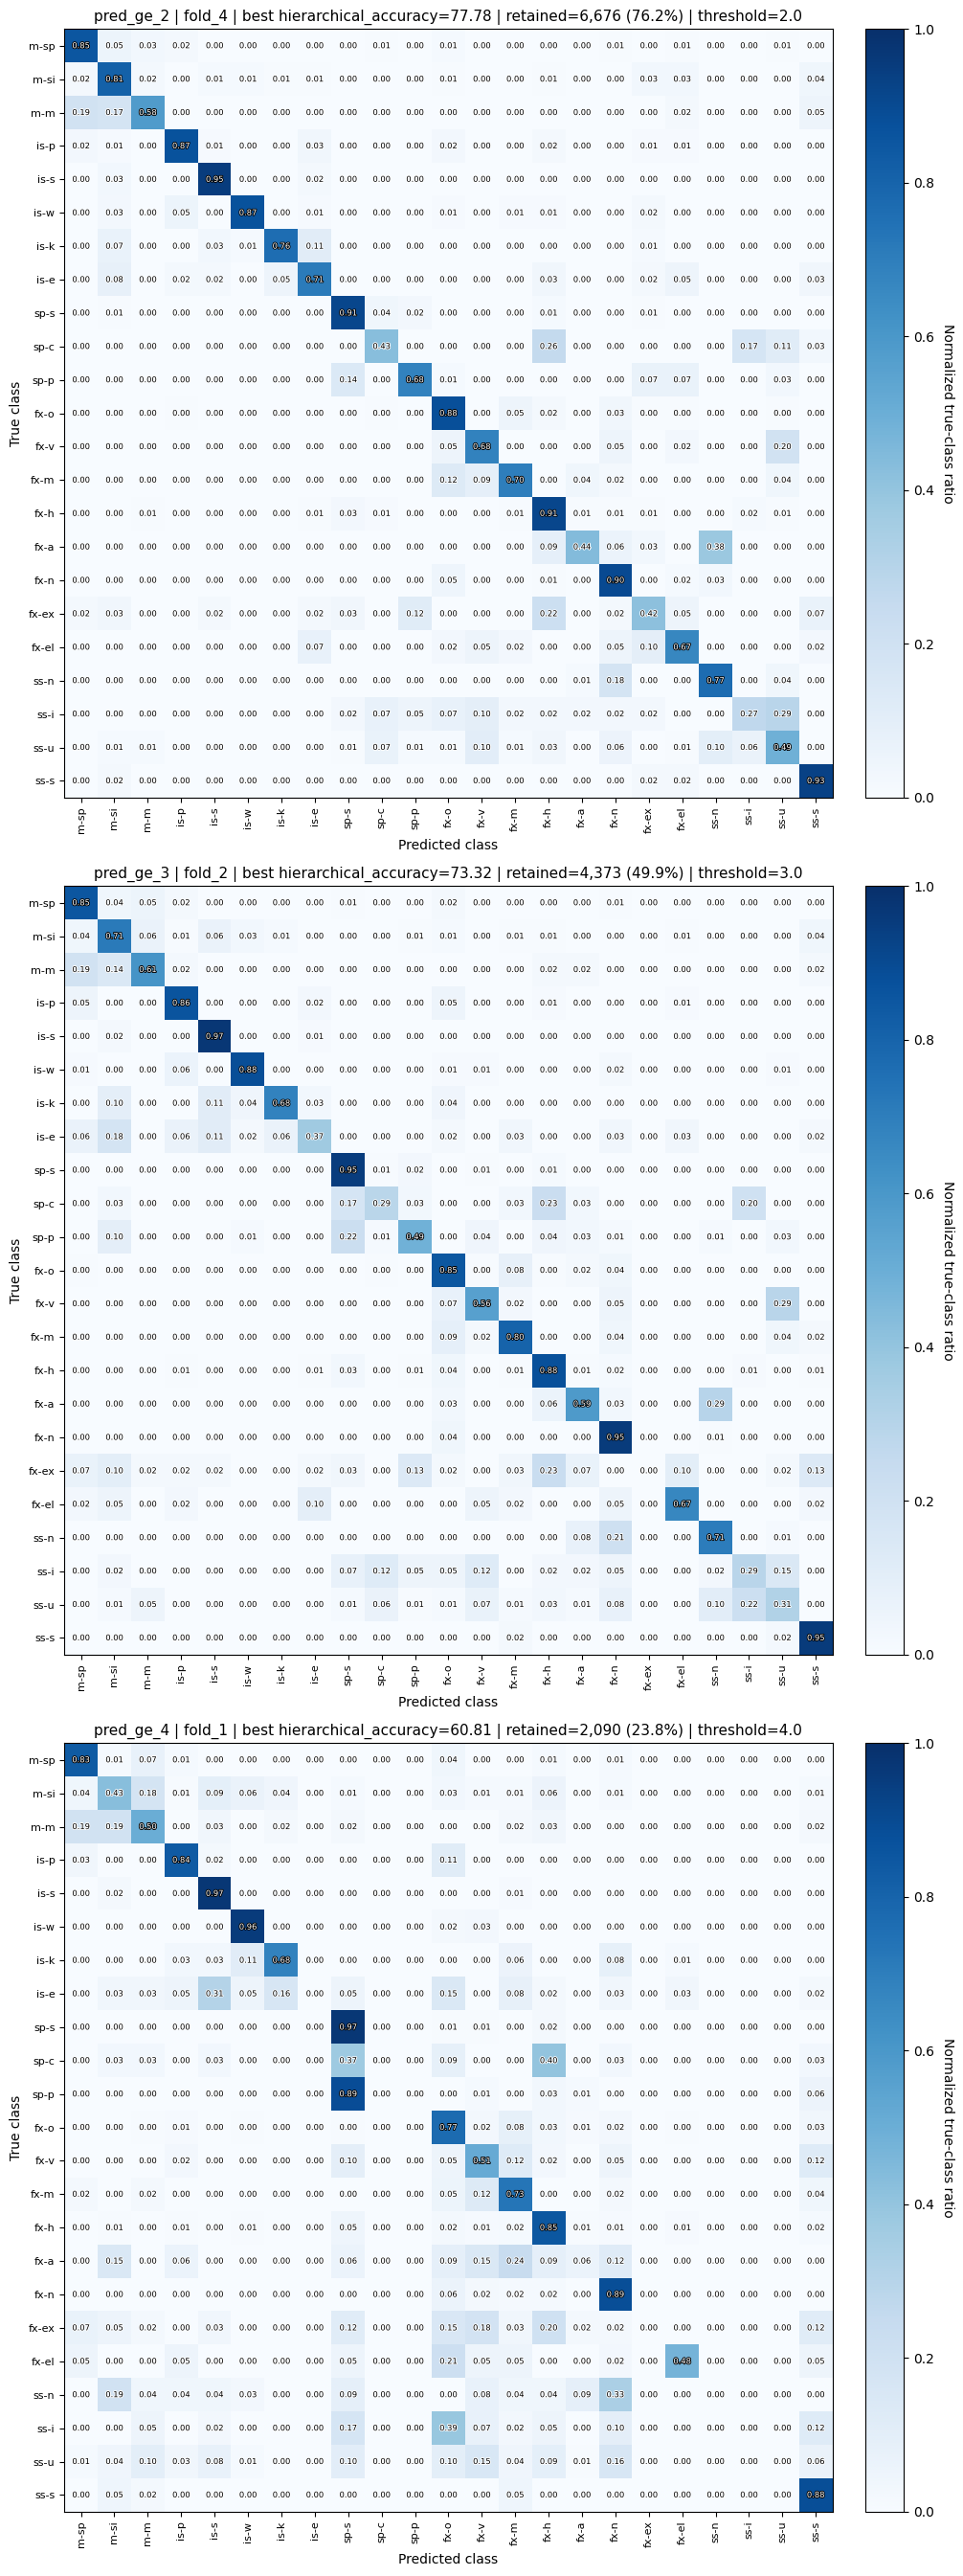


=== Best folds selected for confusion matrix ===
filter_label  threshold mode  split  retained_samples  retained_ratio  best_val_accuracy  accuracy  hierarchical_f1                                                                                                   output_dir
   pred_ge_2        2.0 both fold_4              6676        0.761753          84.569288 77.965328        76.158316 c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_rank_average\pred_ge_2\both\fold_4
   pred_ge_3        3.0 both fold_2              4373        0.498973          91.885714 73.266423        72.894607 c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_rank_average\pred_ge_3\both\fold_2
   pred_ge_4        4.0 both fold_1              2090        0.238476          97.129187 60.036496        68.720375 c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_rank_average\pred_ge_4\both\fold_1

saved best-fold table: C:\Users\solok\Desktop\Dca

,filter_label,threshold,retained_samples,retained_ratio,mode,split,train_samples,val_samples,final_test_samples,best_val_accuracy,accuracy,top_accuracy,macro_accuracy,hierarchical_accuracy,hierarchical_precision,hierarchical_recall,hierarchical_f1,output_dir
4,pred_ge_2,2.0,6676,0.761753,both,fold_4,5341,1335,2192,84.569288,77.965328,88.001825,71.660044,77.778332,77.063409,76.248760,76.158316,c:\Users\solok\Desktop\Dcase baseline\baseline...
2,pred_ge_2,2.0,6676,0.761753,both,fold_2,5341,1335,2192,86.292135,77.600365,87.956204,71.300110,77.538570,76.908606,75.978955,75.867084,c:\Users\solok\Desktop\Dcase baseline\baseline...
3,pred_ge_2,2.0,6676,0.761753,both,fold_3,5341,1335,2192,83.970037,78.102190,87.454380,71.062967,77.047942,77.200037,75.551698,75.741117,c:\Users\solok\Desktop\Dcase baseline\baseline...
1,pred_ge_2,2.0,6676,0.761753,both,fold_1,5341,1335,2192,86.292135,76.916058,87.363139,69.600528,76.221513,75.718916,74.566267,74.768224,c:\Users\solok\Desktop\Dcase baseline\baseline...
0,pred_ge_2,2.0,6676,0.761753,both,fold_0,5340,1336,2192,85.853293,76.733577,86.177007,69.142674,75.436790,75.874071,73.863261,73.620021,c:\Users\solok\Desktop\Dcase baseline\baseline...
7,pred_ge_3,3.0,4373,0.498973,both,fold_2,3498,875,2192,91.885714,73.266423,85.675182,66.231091,73.320094,73.018621,74.032972,72.894607,c:\Users\solok\Desktop\Dcase baseline\baseline...
8,pred_ge_3,3.0,4373,0.498973,both,fold_3,3499,874,2192,91.647597,71.624088,83.941606,65.655601,72.836915,71.394388,73.475295,70.931881,c:\Users\solok\Desktop\Dcase baseline\baseline...
6,pred_ge_3,3.0,4373,0.498973,both,fold_1,3498,875,2192,91.885714,71.578467,83.667883,64.058636,71.301051,70.845998,71.796831,69.461429,c:\Users\solok\Desktop\Dcase baseline\baseline...
9,pred_ge_3,3.0,4373,0.498973,both,fold_4,3499,874,2192,91.304348,69.981752,81.934307,63.471282,70.482129,70.479428,71.058027,67.257029,c:\Users\solok\Desktop\Dcase baseline\baseline...
5,pred_ge_3,3.0,4373,0.498973,both,fold_0,3498,875,2192,92.228571,70.118613,81.888686,62.014518,69.782409,70.375773,72.544518,68.415804,c:\Users\solok\Desktop\Dcase baseline\baseline...


,experiment,filter_label,score_column,threshold,display_threshold,train_pool_samples,retained_samples,retained_ratio,final_test_samples,status,...,accuracy,top_accuracy,macro_accuracy,macro_top_accuracy,hierarchical_accuracy,hierarchical_precision,hierarchical_recall,hierarchical_f1,output_dir,fold_num
0,v4_rank_average_scaled_to_1_5,pred_ge_2,predicted_confidence_score,2.0,2,8764,6676,0.761753,2192,ok,...,77.965328,88.001825,71.660044,83.896619,77.778332,77.063409,76.248760,76.158316,c:\Users\solok\Desktop\Dcase baseline\baseline...,4.0
1,v4_rank_average_scaled_to_1_5,pred_ge_3,predicted_confidence_score,3.0,3,8764,4373,0.498973,2192,ok,...,73.266423,85.675182,66.231091,80.409098,73.320094,73.018621,74.032972,72.894607,c:\Users\solok\Desktop\Dcase baseline\baseline...,2.0
2,v4_rank_average_scaled_to_1_5,pred_ge_4,predicted_confidence_score,4.0,4,8764,2090,0.238476,2192,ok,...,60.036496,76.961679,49.335707,72.276928,60.806318,63.514871,77.170295,68.720375,c:\Users\solok\Desktop\Dcase baseline\baseline...,1.0


WindowsPath('C:/Users/solok/Desktop/Dcase baseline/baseline_confidnce_train/outputs/v4_rank_average/best_fold_confusion_matrices_by_hierarchical_accuracy.png')

In [3]:
from pathlib import Path
import sys
import importlib

ROOT = Path(r"C:\Users\solok\Desktop\Dcase baseline")
sys.path.insert(0, str(ROOT))

import baseline_confidnce_train.confidence_baseline_common as cbc
importlib.reload(cbc)

all_results, best_folds, fig_path = cbc.show_v2_5class_results(
    output_root=ROOT / 'baseline_confidnce_train' / 'outputs' / 'v4_rank_average'
)
display(all_results)
display(best_folds)
fig_path